In [1]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit 

/usr/lib/python3/dist-packages/pythran/tables.py:4553: FutureWarning: In the future `np.bytes` will be defined as the corresponding NumPy scalar.
  obj = getattr(themodule, elem)


In [4]:
def inf_sx4(n_ions):
    S = jmat(n_ions/2, 'x')
    psi = fock(n_ions+1, 0)
    S_8 = expect(S**8, psi)
    S_4 = expect(S**4, psi)
    S_2 = expect(S**2, psi)
    S_6 = expect(S**6, psi)
    return ((S_8 - S_4**2 - (S_6 - S_4*S_2)**2 / (S_4 - S_2**2) ))

def inf_ph_ex(n_ions):
    S = jmat(n_ions/2, 'x')
    psi = fock(n_ions+1, 0)
    S_6 = expect(S**6, psi)
    return S_6

In [5]:
n_ions_min = 200
n_ions_max = 300
n_ions_arr = list(range(n_ions_min, n_ions_max+1))

In [6]:
sx4_inf_arr = [inf_sx4(n) for n in n_ions_arr]
ph_ex_arr = [inf_ph_ex(n) for n in n_ions_arr]

In [8]:
def linear_func(x, a, b):
    return a * x + b

In [9]:
params_sx4, cov_sx4 = curve_fit(linear_func, np.log(n_ions_arr), np.log(sx4_inf_arr))
params_ph,  cov_ph  = curve_fit(linear_func, np.log(n_ions_arr), np.log(ph_ex_arr))

In [11]:
a, b = params_sx4
print('a =', a)
print('b = ', b)
#print(n_ions_arr)
y_pred = linear_func(np.log(n_ions_arr), a, b)

a = 4.024708070469632
b =  -2.5278303831312714


In [12]:
a, b = params_ph
print('a =', a)
print('b = ', b)
#print(n_ions_arr)
y_pred = linear_func(np.log(n_ions_arr), a, b)

a = 3.0081883242310146
b =  -1.504115167800937


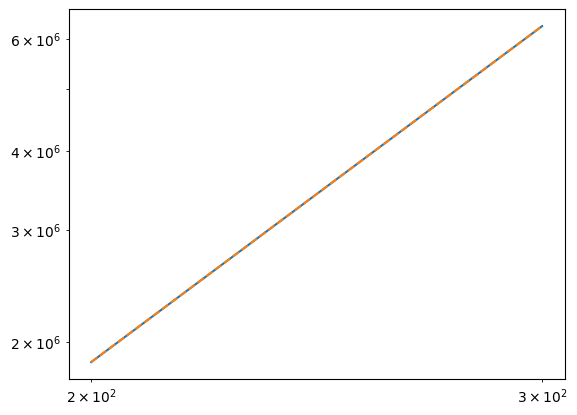

In [54]:
plt.plot(n_ions_arr, inf_arr)
plt.xscale('log')
plt.yscale('log')
plt.plot(n_ions_arr, np.exp(y_pred), linestyle='--')
#plt.xlim(1, 20)
#plt.xscale('log')